In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("delivery_locations.csv")
df.head()

,delivery_location_latitude,delivery_location_longitude,delivery_zone
0,40.7247,-74.0081,Tribeca
1,40.7556,-74.0018,Hell's Kitchen
2,40.7695,-73.9882,Hell's Kitchen
3,40.7476,-73.9954,Chelsea
4,40.7101,-74.0061,Financial District


In [3]:
df.describe()

,delivery_location_latitude,delivery_location_longitude
count,400.000000,400.000000
mean,40.744403,-73.990767
std,0.023782,0.015928
min,40.700300,-74.015000
25%,40.724775,-74.003225
50%,40.743150,-73.994800
75%,40.764125,-73.980050
max,40.794700,-73.946800


In [4]:
zones_df = df[["delivery_zone"]].groupby(by="delivery_zone").size().reset_index(name="count")

In [5]:
y_pos = np.arange(len(zones_df))
people = zones_df["delivery_zone"].to_list()
performance = zones_df["count"].to_list()

In [6]:
fig, ax = plt.subplots()

hbars = ax.barh(y_pos, performance, align='center')
ax.set_yticks(y_pos, labels=people)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Number of Deliveries')
# Label with specially formatted floats
ax.bar_label(hbars)
ax.set_xlim(right=60)  # adjust xlim to fit labels

plt.savefig("deliveries_per_zone.png", dpi=300, bbox_inches="tight")
plt.close()

In [7]:
zones_map = {
    "Financial District": 0,
    "SoHo": 1,
    "Chelsea": 2, 
    "Midtown": 3,
    "Upper East Side": 4,
    "Greenwich Village": 5,
    "Gramercy": 6,
    "Tribeca": 7,
    "Hell's Kitchen": 8,
    "Upper West Side": 9
}

In [8]:
fig, ax = plt.subplots()



ax.set_ylabel("Longitudes")
ax.set_xlabel("Latitudes")

# produce a legend with a cross-section of sizes from the scatter
# handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
# legend2 = ax.legend(handles, labels, loc="upper right", title="Sizes")

plt.savefig("deliveries_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not {'Financial District': {'label': 0, 'lat': (40.7, 40.715), 'lon': (-74.015, -74.0)}, 'SoHo': {'label': 1, 'lat': (40.715, 40.73), 'lon': (-74.01, -73.99)}, 'Chelsea': {'label': 2, 'lat': (40.73, 40.75), 'lon': (-74.005, -73.985)}, 'Midtown': {'label': 3, 'lat': (40.75, 40.77), 'lon': (-73.995, -73.965)}, 'Upper East Side': {'label': 4, 'lat': (40.76, 40.785), 'lon': (-73.975, -73.945)}, 'Greenwich Village': {'label': 5, 'lat': (40.725, 40.74), 'lon': (-74.015, -73.995)}, 'Gramercy': {'label': 6, 'lat': (40.735, 40.75), 'lon': (-73.99, -73.97)}, 'Tribeca': {'label': 7, 'lat': (40.71, 40.725), 'lon': (-74.015, -74.0)}, "Hell's Kitchen": {'label': 8, 'lat': (40.75, 40.77), 'lon': (-74.005, -73.985)}, 'Upper West Side': {'label': 9, 'lat': (40.77, 40.795), 'lon': (-73.985, -73.955)}}

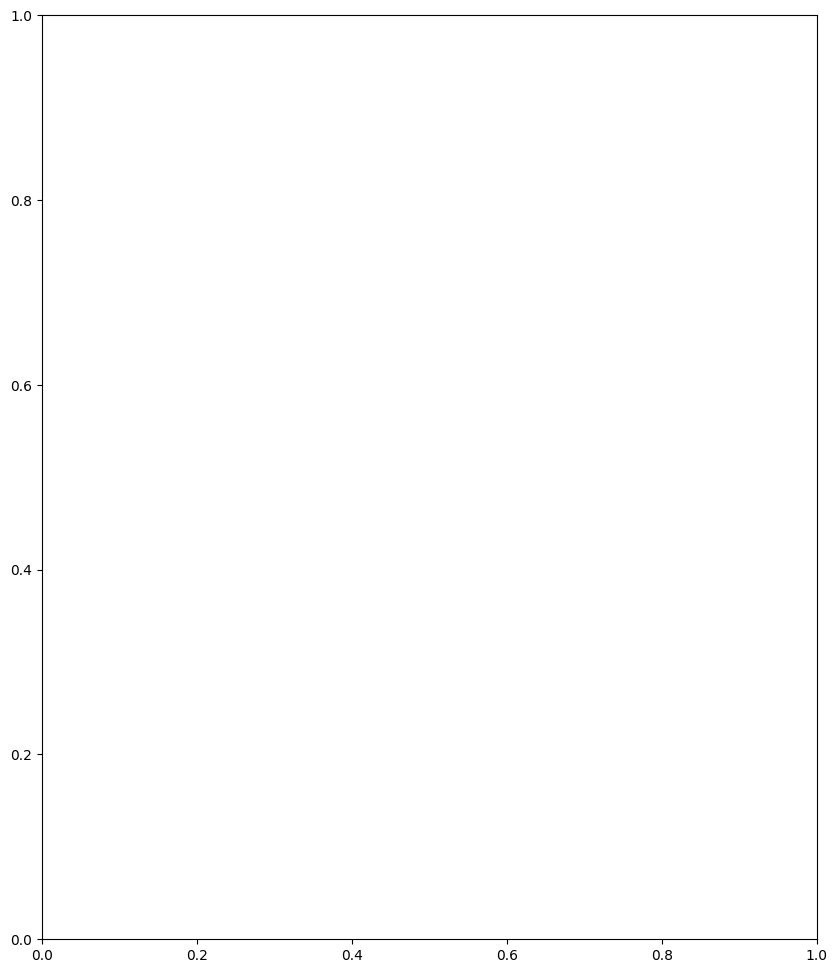

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define the zones with their labels and coordinate ranges
zones = {
    "Financial District": {"label": 0, "lat": (40.700, 40.715), "lon": (-74.015, -74.000)},
    "SoHo": {"label": 1, "lat": (40.715, 40.730), "lon": (-74.010, -73.990)},
    "Chelsea": {"label": 2, "lat": (40.730, 40.750), "lon": (-74.005, -73.985)},
    "Midtown": {"label": 3, "lat": (40.750, 40.770), "lon": (-73.995, -73.965)},
    "Upper East Side": {"label": 4, "lat": (40.760, 40.785), "lon": (-73.975, -73.945)},
    "Greenwich Village": {"label": 5, "lat": (40.725, 40.740), "lon": (-74.015, -73.995)},
    "Gramercy": {"label": 6, "lat": (40.735, 40.750), "lon": (-73.990, -73.970)},
    "Tribeca": {"label": 7, "lat": (40.710, 40.725), "lon": (-74.015, -74.000)},
    "Hell's Kitchen": {"label": 8, "lat": (40.750, 40.770), "lon": (-74.005, -73.985)},
    "Upper West Side": {"label": 9, "lat": (40.770, 40.795), "lon": (-73.985, -73.955)}
}

# Estimated restaurant location
restaurant_lat = 40.74
restaurant_lon = -73.988

# Plot setup
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(latitudes, longitudes, c=zones)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    loc="best", title="Zones")
ax.add_artist(legend1)

for name, data in zones.items():
    lat_min, lat_max = data["lat"]
    lon_min, lon_max = data["lon"]
    width = lon_max - lon_min
    height = lat_max - lat_min
    rect = patches.Rectangle((lon_min, lat_min), width, height, linewidth=1, edgecolor='black', facecolor='lightblue', alpha=0.5)
    ax.add_patch(rect)
    # Zone label at center
    label_x = lon_min + width / 2
    label_y = lat_min + height / 2
    ax.text(label_x, label_y, f'{data["label"]}\n{name}', ha='center', va='center', fontsize=8)

# Plot the restaurant location
ax.plot(restaurant_lon, restaurant_lat, marker='*', color='red', markersize=15, label='Restaurant')

# Axis labels and legend
ax.set_title('Delivery Zones Around Restaurant in Manhattan', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig("deliver")